In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
total_dataset = pd.read_csv('/Users/mahaswetasarkar/Downloads/Social_Network_Ads.csv')

In [87]:
total_dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [88]:
df = total_dataset.iloc[:,2:]
#Only selected required column

In [89]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [90]:
df.sample(5)

,Age,EstimatedSalary,Purchased
226,36,126000,1
232,40,107000,1
392,45,45000,1
209,46,22000,0
47,27,54000,0


In [91]:
X = df.iloc[:,:2]

In [92]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [93]:
y = df.iloc[:,-1]

In [94]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

# Train_Test_Split:

In [95]:
from sklearn.model_selection import train_test_split

In [96]:
#help(train_test_split)

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [98]:
X_train.shape

(268, 2)

In [99]:
X_test.shape

(132, 2)

# Standard Scaler:

In [100]:
from sklearn.preprocessing import StandardScaler

In [101]:
scaler = StandardScaler()

In [102]:
Scaled_X_train = scaler.fit_transform(X_train)

In [103]:
#Scaled_X_train

In [104]:
Scaled_X_test = scaler.transform(X_test)

In [105]:
#Scaled_X_test

# Create Pandas Dataframe 

In [106]:
Scaled_X_train = pd.DataFrame(Scaled_X_train,columns = X_train.columns)

In [107]:
Scaled_X_train

,Age,EstimatedSalary
0,-1.354299,-1.481447
1,0.421010,2.338106
2,0.815523,0.780903
3,-0.959786,-0.306200
4,0.125125,0.780903
...,...,...
263,1.012780,-1.158254
264,-0.861157,-0.776299
265,-0.170759,-0.511868
266,-1.058414,-0.453106


# For Scaled Data:

In [109]:
np.round(Scaled_X_train.describe(),1)
#Mean = 0
# Standard deviation = 1

,Age,EstimatedSalary
count,268.0,268.0
mean,-0.0,-0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.4


# Before Scaling:

In [111]:
np.round(X_train.describe(),1)
#Mean = 37.7
#Standard deviation = 10.2

,Age,EstimatedSalary
count,268.0,268.0
mean,37.7,69421.6
std,10.2,34099.1
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,87000.0
max,60.0,150000.0


# Effect on data distribution/spread/shape before and after scaling:

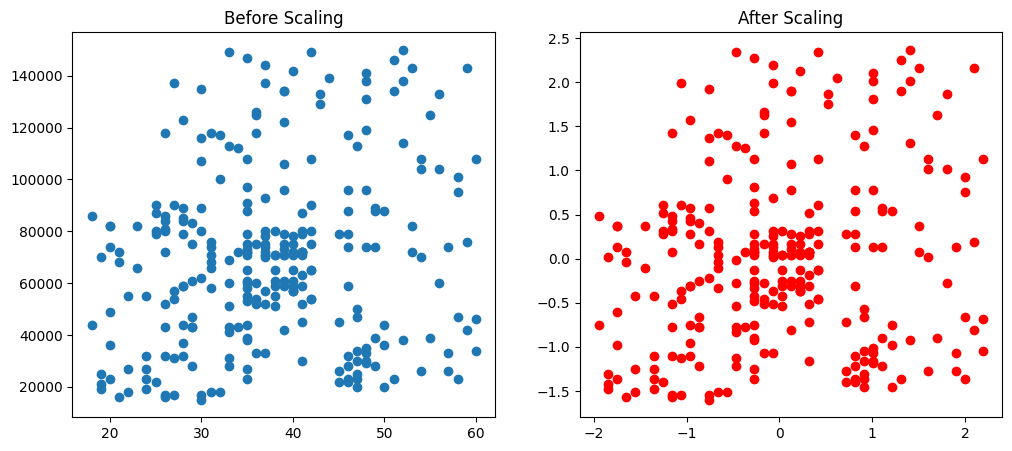

In [120]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(Scaled_X_train['Age'], Scaled_X_train['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

#before scaling and after scaling data spread is visually same only we can notice change in x and y axis range 

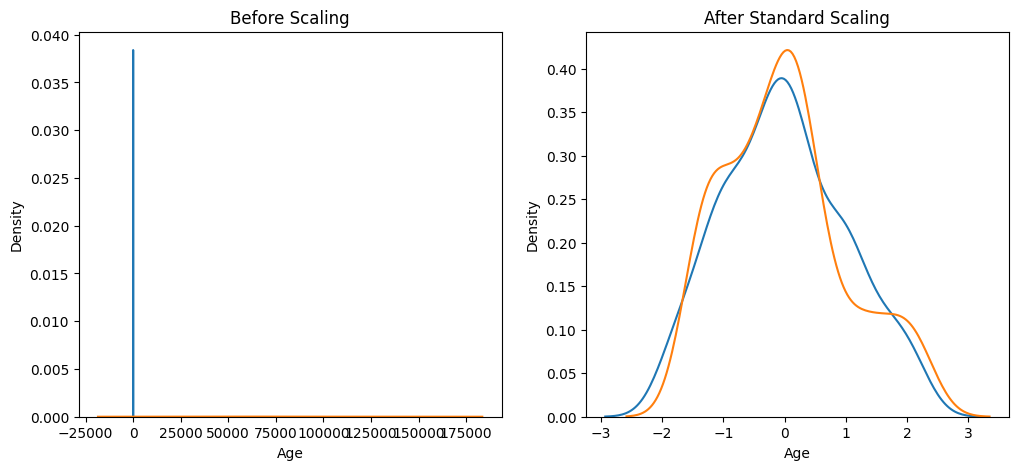

In [123]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(Scaled_X_train['Age'], ax=ax2)
sns.kdeplot(Scaled_X_train['EstimatedSalary'], ax=ax2)
plt.show()

#Before scaling data both 'Age' and 'EstimatedSalary' scale was different but after scaling both are almost in a same scale 

<Axes: title={'center': 'After Standard Scaling'}, xlabel='Age', ylabel='Density'>

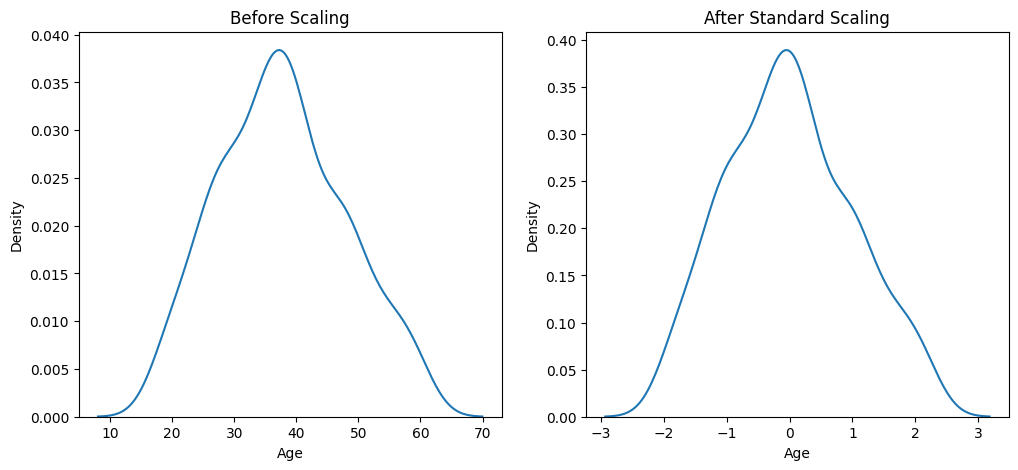

In [124]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(Scaled_X_train['Age'], ax=ax2)

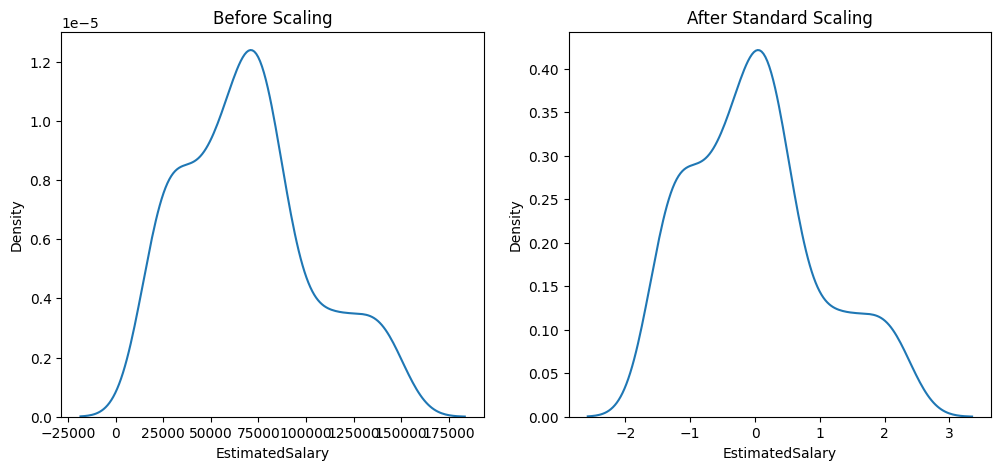

In [125]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(Scaled_X_train['EstimatedSalary'], ax=ax2)
plt.show()